# 1. Introduction
Efficient data retrieval is one of the central challenges in database system design. As
datasets grow in size, performing operations such as search, insertion, deletion, and range
queries using naive approaches becomes increasingly inefficient. Traditional brute-force
techniques rely on sequential scanning of records, which results in linear-time complexity
and poor scalability for large datasets.
To address this limitation, modern database systems employ indexing structures that
enable faster lookup and ordered traversal of records. One of the most widely used in-
dexing structures in database management systems (DBMS) is the B+ Tree. B+ Trees
maintain sorted data and support logarithmic-time search, insertion, deletion, and effi-
cient range queries.
In this project, we designed and implemented an in-memory database indexing mod-
ule using a B+ Tree as the primary storage and retrieval structure. The system sup-
ports multiple databases, schema-based table creation, indexed record storage, update
operations, range queries, deletion operations, and visualization of tree structures. Addi-
tionally, a brute-force baseline implementation was developed for comparison to evaluate
performance improvements achieved using B+ Trees.
The objective of this assignment is to demonstrate how B+ Trees improve database
indexing performance compared to linear-search-based storage models through both im-
plementation and benchmarking experiments.

# 2. Implementation
The system is organized into multiple modular components that collectively simulate a
lightweight database indexing engine. These include the Database Manager layer, Table
abstraction layer, B+ Tree indexing structure, brute-force baseline implementation, and
benchmarking utilities.
## 2.1 Database Manager
The DatabaseManager module provides high-level functionality for managing multiple
databases and their associated tables. It maintains an in-memory registry that stores
database objects and enables creation, deletion, retrieval, and listing of databases and
tables.

Each database can contain multiple tables defined using user-provided schemas. The
manager ensures duplicate database or table names are not allowed and provides safe
access to table instances when requested.
This layer simulates the metadata management functionality present in real DBMS
systems.
## 2.2 Table Abstraction Layer
Each table is defined using a schema consisting of attribute names and their data types.
A configurable search key is selected during table creation, which determines the indexing
attribute stored inside the B+ Tree.
Supported operations include:
- Record validation using schema constraints
- Record insertion
- Record retrieval using search keys
- Record updates (including key modification)
- Range queries
- Record deletion
- Retrieval of all stored records
The table internally uses a B+ Tree structure to maintain sorted records based on
the search key.
## 2.3 B+ Tree Structure
The core indexing component of the system is the B+ Tree implementation. The tree
consists of internal nodes that store separator keys and leaf nodes that store actual key-
value pairs.
Important features of the implementation include:
- Configurable minimum degree parameter
- Automatic node splitting during insert operations
- Linked leaf-node structure for efficient sequential traversal
- Support for update operations
- Range query optimization using leaf-level chaining
- Tree visualization using Graphviz
Insertion is handled using a recursive non-full insertion strategy. When nodes exceed
capacity limits, they are split and separator keys are promoted upward to maintain tree
balance.
Leaf nodes are connected using next pointers, which allow efficient traversal during
range queries without repeatedly traversing internal nodes.

## 2.4 Deletion Strategy
Deletion in the B+ Tree is performed using a hierarchical approach. The key is first located by traversing from the root to the appropriate leaf node in O(log n) time. Once found, it is removed directly from the leaf.

## 2.5 Brute Force Baseline Implementation
To evaluate indexing performance improvements, a brute-force database structure was
implemented using a simple list-based storage model.
Supported operations include:
- Sequential insertion
- Linear search
- Range query scanning
- Deletion by list removal


This structure serves as a baseline comparison model for benchmarking experiments.

This notebook exercises all major functions across the module:
- Database creation, listing, and deletion
- Table creation, listing, insertion, update, range query, and deletion
- Direct B+ Tree and brute-force operations
- Performance comparison of B+ Tree vs brute-force for insert/search/range-query/delete

All sections are runnable in order.

In [2]:
import os
import sys
import random
import graphviz

# Ensure imports work whether the notebook runs from Module_A or Module_A/database.
module_root = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "database" else os.getcwd()
if module_root not in sys.path:
    sys.path.insert(0, module_root)

from database.db_manager import DatabaseManager
from database.table import Table
from database.bplustree import BPlusTree
from database.bruteforce import BruteForceDB
from database.performance import PerformanceAnalyzer

random.seed(42)
print("Module root:", module_root)
print("Imports loaded successfully.")

Module root: c:\Users\dhruv\Desktop\IIT\databases\Assignment 2\CS432_Track1\Module_A
Imports loaded successfully.


In [3]:
# DatabaseManager workflow: create/list/delete databases and create/list/delete tables.
manager = DatabaseManager()

print("Create databases:", manager.create_database("college"), manager.create_database("analytics"))
print("Create duplicate database (expected False):", manager.create_database("college"))
print("Databases:", manager.list_databases())

student_schema = {"id": int, "name": str, "cgpa": float}
course_schema = {"code": str, "title": str, "credits": int}

print("Create tables:", manager.create_table("college", "students", student_schema, order=5, search_key="id"))
print("Create table:", manager.create_table("college", "courses", course_schema, order=4, search_key="code"))
print("Duplicate table create (expected False):", manager.create_table("college", "students", student_schema))
print("Tables in college:", manager.list_tables("college"))

students = manager.get_table("college", "students")
courses = manager.get_table("college", "courses")
print("Fetched students table type:", type(students).__name__)
print("Fetched courses table type:", type(courses).__name__)

Create databases: True True
Create duplicate database (expected False): False
Databases: ['analytics', 'college']
Create tables: True
Create table: True
Duplicate table create (expected False): False
Tables in college: ['courses', 'students']
Fetched students table type: Table
Fetched courses table type: Table


In [4]:
# Table workflow: validate, insert, get, get_all, update, range_query, delete.
records = [
    {"id": 101, "name": "Aditi", "cgpa": 8.9},
    {"id": 109, "name": "Rohan", "cgpa": 7.8},
    {"id": 115, "name": "Meera", "cgpa": 9.4},
    {"id": 123, "name": "Arjun", "cgpa": 8.1},
]

students.validate_record(records[0])
for record in records:
    inserted_key = students.insert(record)
    print("Inserted student key:", inserted_key)

print("Get id=109:", students.get(109))
print("All students:", students.get_all())

print("Update id=109 (same key):", students.update(109, {"cgpa": 8.0, "name": "Rohan Sharma"}))
print("Move key 123 -> 130:", students.update(123, {"id": 130, "name": "Arjun Rao"}))
print("Range query id 105..140:", students.range_query(105, 140))

print("Delete id=101:", students.delete(101))
print("After deletion:", students.get_all())

Inserted student key: 101
Inserted student key: 109
Inserted student key: 115
Inserted student key: 123
Get id=109: {'id': 109, 'name': 'Rohan', 'cgpa': 7.8}
All students: [{'id': 101, 'name': 'Aditi', 'cgpa': 8.9}, {'id': 109, 'name': 'Rohan', 'cgpa': 7.8}, {'id': 115, 'name': 'Meera', 'cgpa': 9.4}, {'id': 123, 'name': 'Arjun', 'cgpa': 8.1}]
Update id=109 (same key): True
Move key 123 -> 130: True
Range query id 105..140: [{'id': 109, 'name': 'Rohan Sharma', 'cgpa': 8.0}, {'id': 115, 'name': 'Meera', 'cgpa': 9.4}, {'id': 130, 'name': 'Arjun Rao', 'cgpa': 8.1}]
Delete id=101: True
After deletion: [{'id': 109, 'name': 'Rohan Sharma', 'cgpa': 8.0}, {'id': 115, 'name': 'Meera', 'cgpa': 9.4}, {'id': 130, 'name': 'Arjun Rao', 'cgpa': 8.1}]


Tree after inserting 12:


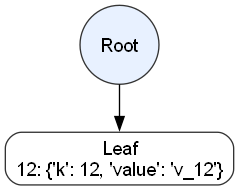

Tree after inserting 6:


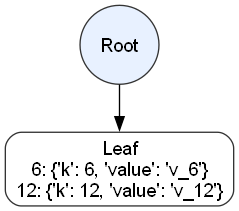

Tree after inserting 19:


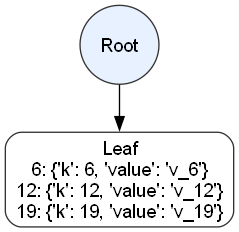

Tree after inserting 3:


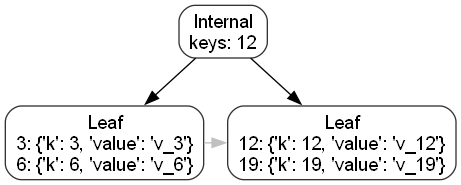

Tree after inserting 9:


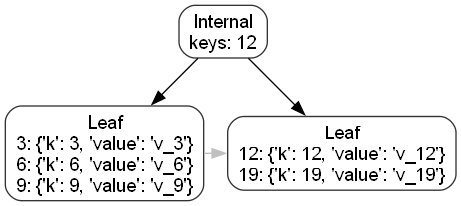

Tree after inserting 15:


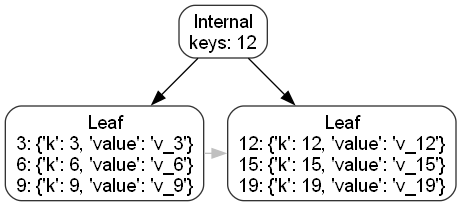

Tree after inserting 21:


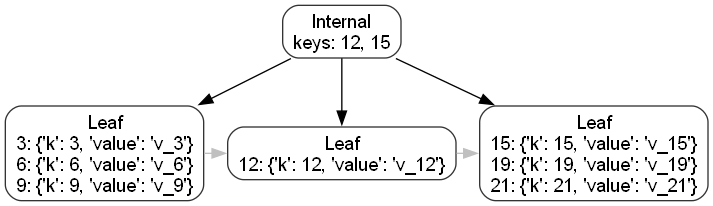

Tree after inserting 18:


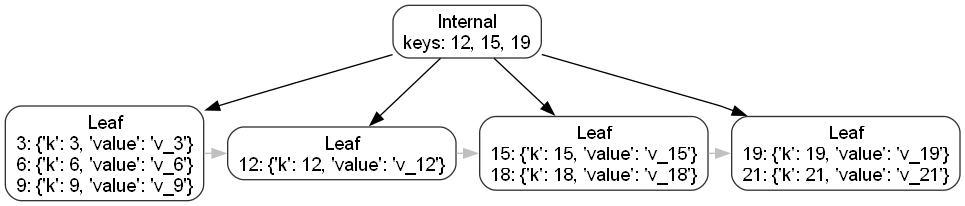

Tree after inserting 24:


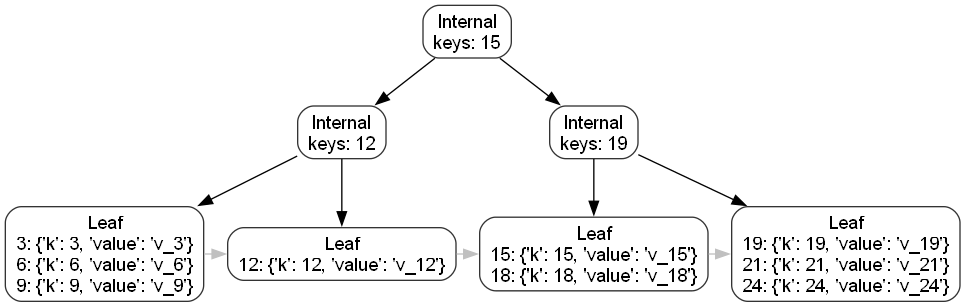

Tree after inserting 27:


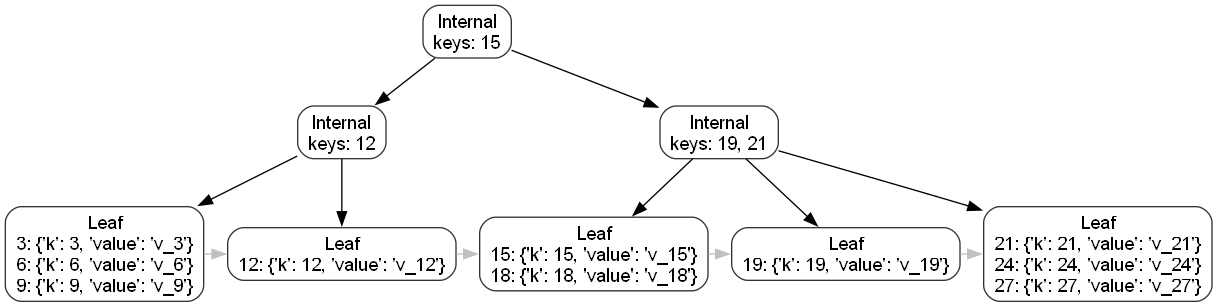

Tree after inserting 30:


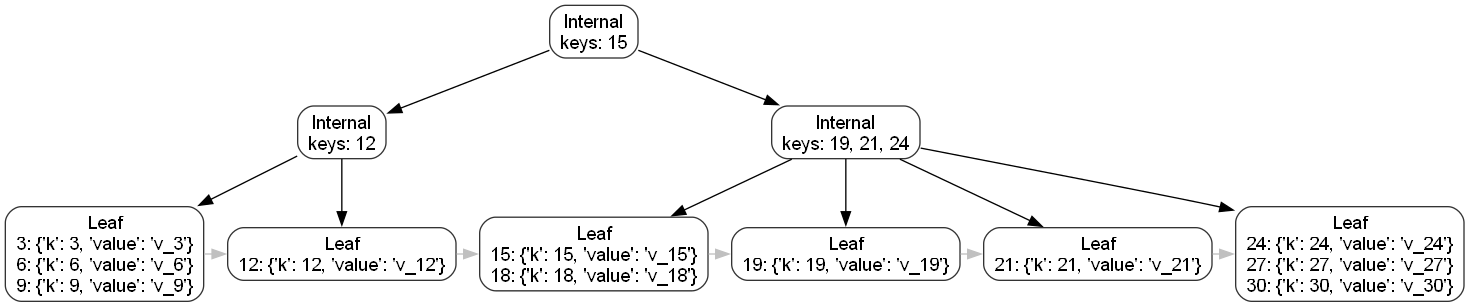

In [5]:
tree = BPlusTree(t=2)

for key in [12, 6, 19, 3, 9, 15, 21, 18, 24, 27, 30]:
    tree.insert(key, {"k": key, "value": f"v_{key}"})
    print(f"Tree after inserting {key}:")
    try:
        from IPython.display import display
        display(tree.visualize_tree())
    except Exception as exc:
        print("Tree visualization skipped:", exc)

Search 15: {'k': 15, 'value': 'v_15'}
Update 15: True
Range query 7..19: [(9, {'k': 9, 'value': 'v_9'}), (12, {'k': 12, 'value': 'v_12'}), (15, {'k': 15, 'value': 'v_15_updated'}), (18, {'k': 18, 'value': 'v_18'}), (19, {'k': 19, 'value': 'v_19'})]
Tree before delete:


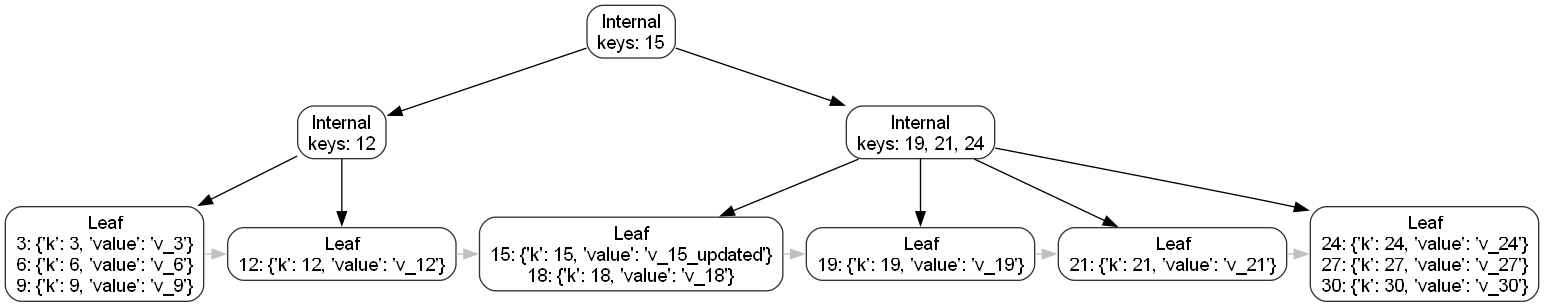

Delete 9: True
All nodes (leaf order): [(3, {'k': 3, 'value': 'v_3'}), (6, {'k': 6, 'value': 'v_6'}), (12, {'k': 12, 'value': 'v_12'}), (15, {'k': 15, 'value': 'v_15_updated'}), (18, {'k': 18, 'value': 'v_18'}), (19, {'k': 19, 'value': 'v_19'}), (21, {'k': 21, 'value': 'v_21'}), (24, {'k': 24, 'value': 'v_24'}), (27, {'k': 27, 'value': 'v_27'}), (30, {'k': 30, 'value': 'v_30'})]
Tree after delete:


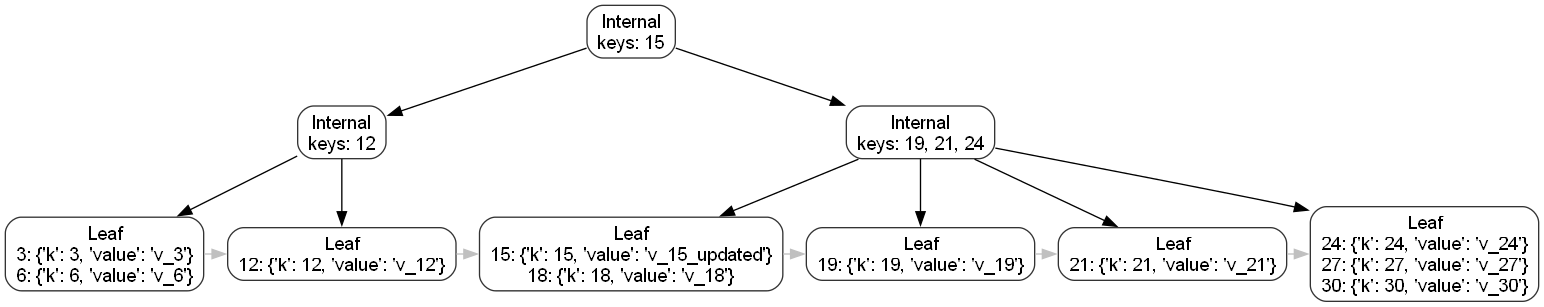

In [6]:
# Direct BPlusTree usage: insert, search, update, range query, delete, get_all, visualize.
print("Search 15:", tree.search(15))
print("Update 15:", tree.update(15, {"k": 15, "value": "v_15_updated"}))
print("Range query 7..19:", tree.range_query(7, 19))

print("Tree before delete:")
try:
    from IPython.display import display
    display(tree.visualize_tree())
except Exception as exc:
    print("Tree visualization skipped:", exc)

print("Delete 9:", tree.delete(9))
print("All nodes (leaf order):", tree.get_all())

print("Tree after delete:")
try:
    from IPython.display import display
    display(tree.visualize_tree())
except Exception as exc:
    print("Tree visualization skipped:", exc)

# 4 Visualization of Tree Structure
Tree visualization was implemented using the Graphviz library. Internal nodes and leaf
nodes are rendered separately, and dashed edges represent leaf-level chaining connections.
Visualization provides insight into:
- Node splitting behavior
- Separator key promotion
- Tree height growth
- Leaf-node linking
These graphical representations help validate correctness of the indexing structure
and improve interpretability of tree operations.
# 5 Conclusion
This project demonstrates the effectiveness of B+ Trees as an indexing mechanism for
database systems. Compared to brute-force storage models, the B+ Tree structure signif-
icantly improves search and range query performance while maintaining ordered storage.
Although deletion operations are currently implemented using a rebuild-based strat-
egy, the system successfully maintains correctness and structural balance after updates.
Future improvements to this system may include implementing merge-based deletion
algorithms, adding persistent disk storage support, integrating buffer management tech-
niques, and supporting multiple indexing attributes per table.
These extensions would further align the system with real-world database indexing
engines.

In [6]:
# Direct BruteForceDB usage.
brute = BruteForceDB()
for key in [2, 5, 8, 11, 14, 17, 20]:
    brute.insert(key)

print("Brute search 11:", brute.search(11))
print("Brute range query 6..18:", brute.range_query(6, 18))
brute.delete(11)
print("Brute search 11 after delete:", brute.search(11))

Brute search 11: True
Brute range query 6..18: [8, 11, 14, 17]
Brute search 11 after delete: False


Benchmarked sizes: 100 from 100 to 99100


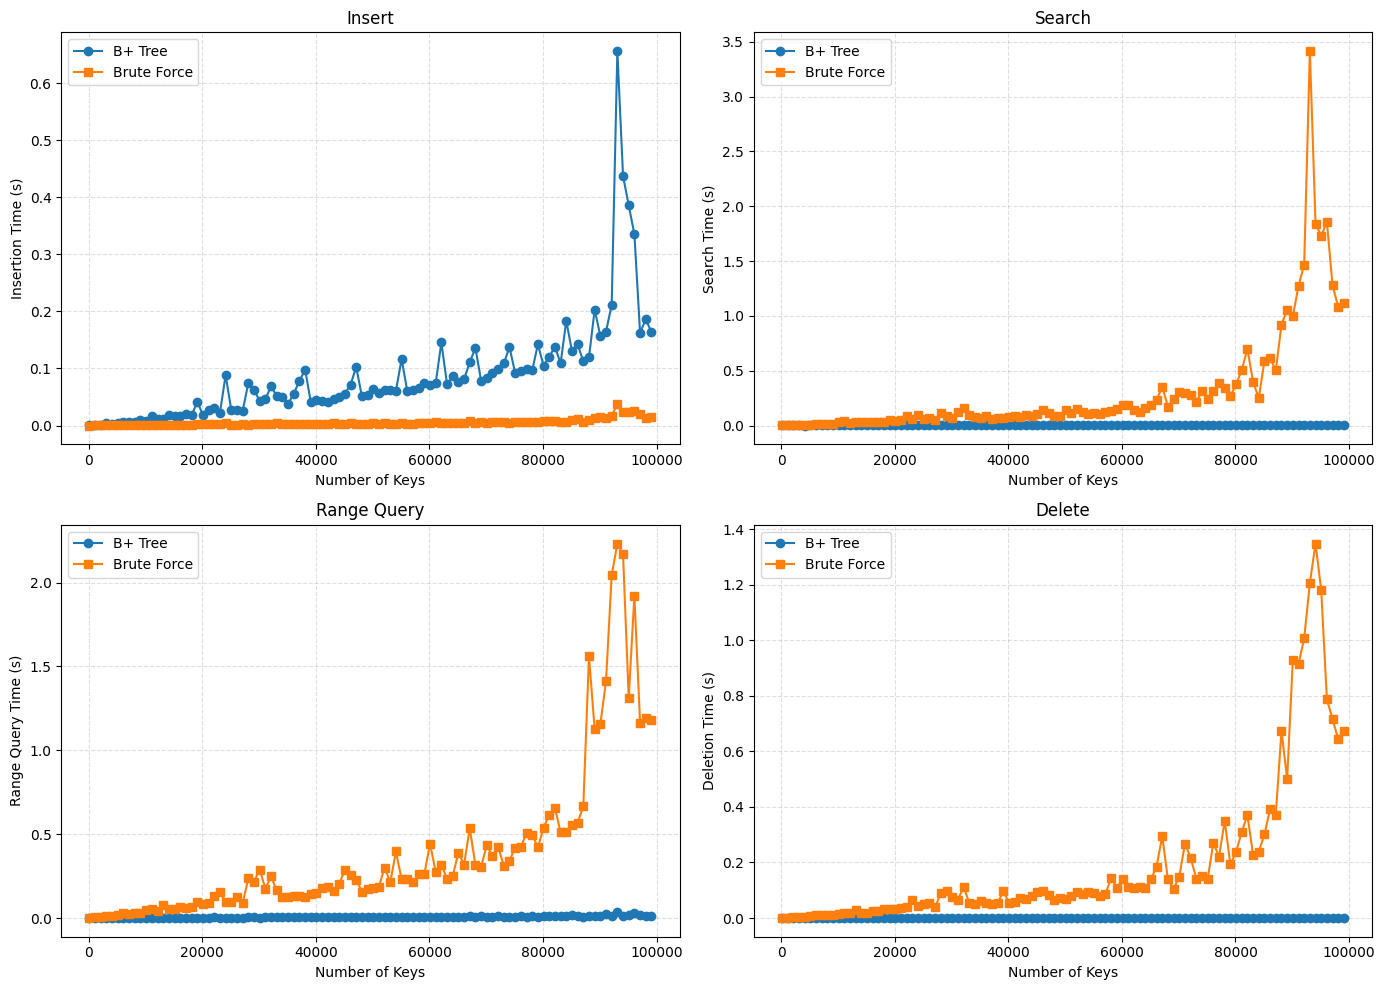

Saved plot: full_range_performance.png


In [7]:
# Performance comparison using configurable random key sizes.
sizes = list(range(100, 100000, 1000))

analyzer = PerformanceAnalyzer(tree_degree=50, seed=42)
results = analyzer.run_tests(
    sizes=sizes,
    search_count=250,
    range_query_count=120,
    delete_count=150,
)

print("Benchmarked sizes:", len(results["sizes"]), "from", results["sizes"][0], "to", results["sizes"][-1])
analyzer.plot_results(results, save_prefix="full_range", show=True)
print("Saved plot: full_range_performance.png")

Advanced benchmark sizes: 100 from 100 to 99100


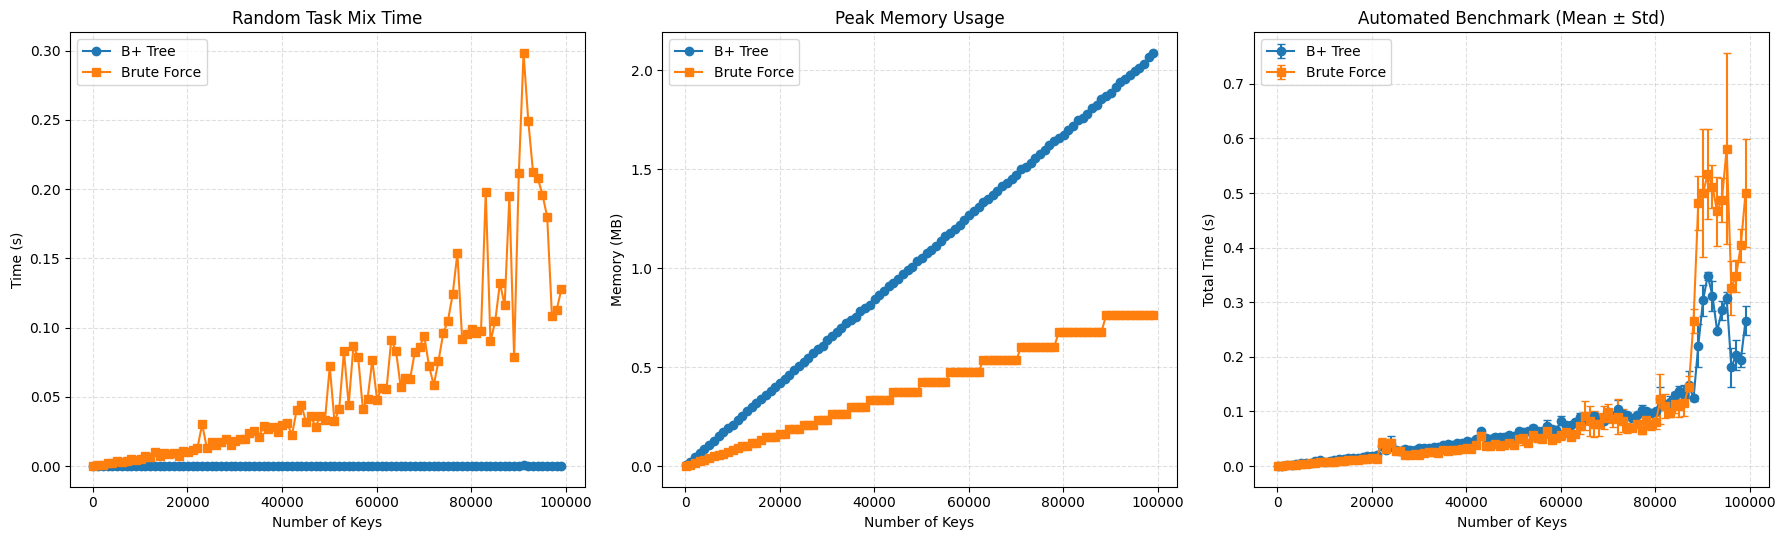

Saved plot: advanced_metrics_advanced_performance.png


In [8]:
# Advanced benchmarking for the remaining metrics: random workload, memory usage, and automated repeated runs.
advanced_sizes = list(range(100, 100000, 1000))
analyzer = PerformanceAnalyzer(tree_degree=50, seed=42)

advanced_results = analyzer.run_advanced_tests(
    sizes=advanced_sizes,
    random_task_count=100,
    benchmark_runs=3,
    search_count=25,
    range_query_count=12,
    delete_count=15,
)

print("Advanced benchmark sizes:", len(advanced_results["sizes"]), "from", advanced_results["sizes"][0], "to", advanced_results["sizes"][-1])
analyzer.plot_advanced_results(advanced_results, save_prefix="advanced_metrics", show=True)
print("Saved plot: advanced_metrics_advanced_performance.png")

# 3. Performance Analysis
Performance evaluation was conducted using automated benchmarking experiments across
increasing dataset sizes. Operations tested include insertion, search, range queries, dele-
tion, mixed workloads, and memory consumption.
# 3.1 Insertion Performance
Insertion time increases gradually for both approaches as dataset size increases. However,
the B+ Tree maintains better scalability compared to brute-force insertion due to its
logarithmic complexity.

# 3.2 Search Performance
Search performance shows significant improvement when using B+ Trees. While brute-
force search time increases linearly with dataset size, B+ Tree search remains nearly
constant due to logarithmic traversal depth.
# 3.3 Range Query Performance
Range queries benefit substantially from the linked leaf-node structure of the B+ Tree.
Instead of scanning the entire dataset, traversal begins at the first matching leaf node
and continues sequentially using next pointers.
This results in major performance improvements compared to brute-force implemen-
tations.
# 3.4 Deletion Performance
Deletion performance in the B+ Tree implementation is efficient and generally takes less time compared to brute-force storage for large datasets. This is because B+ trees perform deletion in O(log n) time by directly locating the key through hierarchical indexing and making only local adjustments such as borrowing or merging nodes when required.

# 3.5 Memory Usage
Memory consumption for the B+ Tree increases faster than brute-force storage due to
additional structural overhead such as internal nodes, child pointers, and linked leaf
references.
However, this overhead enables significantly faster query execution.

# 3.6 Random Task Workload Benchmark
Under mixed workloads involving insertion, search, deletion, and range queries, the B+
Tree demonstrates superior performance scalability compared to brute-force implemen-
tations.
These experiments confirm that indexed storage structures are essential for real-world
database workloads.

In [ ]:
# Cleanup workflow: delete table and database, and list final state.
print("Delete table courses:", manager.delete_table("college", "courses"))
print("Remaining tables in college:", manager.list_tables("college"))

print("Delete database college:", manager.delete_database("college"))
print("Final databases:", manager.list_databases())

Delete table courses: True
Remaining tables in college: ['students']
Delete database college: True
Final databases: ['analytics']


Github Repo: https://github.com/dhruv01032005/CS432_Track1_Submission

Video link: https://drive.google.com/file/d/14ifw79fC0qx9IS8pk1Y8sag3pVPRFsOo/view?usp=sharing